In [ ]:
# from ultralytics import RTDETR

# model = RTDETR("rtdetr-l.pt")
# model.info()

# results = model.train(data='./Scananagrams.yolov8', epochs = 50, imgsz=640)


image 1/1 c:\IzzysWorkshop\PeelBack\TestImage.jpg: 640x640 16 Tiles, 429.6ms
Speed: 3.0ms preprocess, 429.6ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
average Tile Length: 315.5625


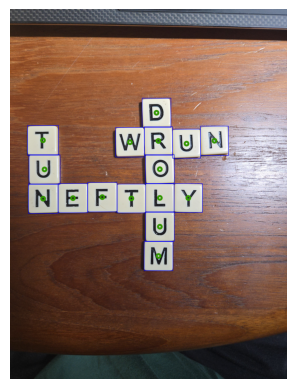

In [65]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import RTDETR
import numpy as np


imagePath = 'TestImage.jpg'

image = cv2.imread('TestImage.jpg', cv2.IMREAD_COLOR_RGB)

drawOn = image.copy()

myModel = RTDETR('runs/detect/train/weights/best.pt')
result = myModel.predict(imagePath)

boxes = result[0].boxes.xyxy.cpu().numpy()
centers = []
avgTileLen = 0

for box in boxes:
    x1,y1,x2,y2 = map(int,box)
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    centers.append([xAvg,yAvg])
    avgTileLen += x2-x1
    avgTileLen += y2-y1

    cv2.circle(drawOn, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn, (x1,y1),(x2,y2), (0,0,250),3)

centers = np.asarray(centers)

avgTileLen/= len(boxes)*2
print(f'average Tile Length: {avgTileLen}')
plt.imshow(drawOn)
plt.axis('off')
plt.show()

In [80]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(centers)
indices = neigh.kneighbors(centers, return_distance=False)

array([[ 0,  9,  3,  7,  6],
       [ 1, 10,  5, 15, 14],
       [ 2,  7,  3,  0,  9],
       [ 3,  7,  0,  2,  9],
       [ 4,  5,  1, 15, 11],
       [ 5,  4,  1, 15, 10],
       [ 6, 13,  9, 12, 15],
       [ 7,  2,  3,  0,  9],
       [ 8, 12, 13,  6, 11],
       [ 9,  6,  0, 13,  3],
       [10,  1, 14,  5, 15],
       [11, 13, 12, 15,  5],
       [12, 13,  8,  6, 11],
       [13, 11,  6, 15, 12],
       [14,  1, 10, 15,  6],
       [15,  1, 13,  5, 14]])

In [ ]:
#Centers argument should be passed a list of 4 nearest neighbors NOT entire list of centers
def findNeighbor(tile, avgTileLen, centers):
    # exampleImg = image.copy()
    moe = avgTileLen * .3
    neighbors = {'up':None,'down':None,'left':None,'right':None}
    tileX = tile[0]
    tileY = tile[1]
    for point in centers:
        otherX = point[0]
        otherY = point[1]
        staticXCheck = (otherX-moe < tileX < otherX+moe)
        staticYCheck = (otherY-moe <tileY<otherY+moe)
        #Check for up neighbor
        if( neighbors['up'] is None and staticXCheck and (otherY - avgTileLen - moe < tileY < otherY - avgTileLen + moe) ):
            neighbors['up'] = point
            # cv2.circle(exampleImg, (otherX,otherY), 20, (0,0,0), 25)

        #Check for down neighbor
        if(neighbors['down'] is None and staticXCheck and (otherY+avgTileLen-moe < tileY < otherY+avgTileLen+moe)):
            neighbors['down'] = point
            # cv2.circle(exampleImg, (otherX,otherY), 20, (0,0,0), 25)

        if(neighbors['left'] is None and staticYCheck and (otherX-avgTileLen-moe < tileX < otherX-avgTileLen+moe)):
            neighbors['left'] = point
            # cv2.circle(exampleImg, (otherX,otherY), 20, (0,0,0), 25)

        if(neighbors['right'] is None and staticYCheck and (otherX+avgTileLen-moe < tileX < otherX+avgTileLen+moe)):
            neighbors['right'] = point
            # cv2.circle(exampleImg, (otherX,otherY), 20, (0,0,0), 25)

    # cv2.circle(exampleImg,(tileX,tileY), 25, (250, 40,40),25)
    # plt.imshow(exampleImg)
    # plt.show()
    return neighbors

In [128]:
board = np.zeros((6,7))
centersAdj = centers.copy()
centersAdj = centersAdj//avgTileLen
farLeft = centersAdj[np.argmin(centersAdj[:,0])][0]
farTop = centersAdj[np.argmin(centersAdj[:,1])][1]
centersAdj[:,0] -=farLeft
centersAdj[:,1]-= farTop 
for x in centersAdj:
    x1 = int(x[0])
    y1 = int(x[1])
    board[y1,x1]=1

for row in board:
    toPrint =''
    for col in row:
        toPrint+=str(int(col))
    print(toPrint)

0000100
1001111
1000100
1111110
0000100
0000100
